In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from astrotools import constants as c
from astrotools.nbody import integrators as it
from astrotools.nbody import twobody as tb

## Problem 1: Build the Module

### Checking hill_radius

In [2]:
m_planet = c.M_EARTH
a = c.AU # 1 AU in meters
r_H_calc = tb.hill_radius(a, m_planet)

print("Hill radius of Earth is: %.2g m" %r_H_calc)
print("This matches the accepted value!")

Hill radius of Earth is: 1.5e+09 m
This matches the accepted value!


### Checking roche_density

In [3]:
a_Mimas = 1.855e8
m_Saturn = 5.6834e26

roche_Mimas = tb.roche_density(a_Mimas, m_Saturn)
print("The roche density of Saturn at the orbit of Mimas is: %.2g kg m^-3" %roche_Mimas)

The roche density of Saturn at the orbit of Mimas is: 64 kg m^-3


### Checking the integration over 1 orbit using rk4_step

In [4]:
e_check = 0.0

P = tb.orbital_period(a)
y0 = tb.initial_conditions(a, e_check)

dt_arr = [P/1000, P/2000]


In [5]:
func = tb.kepler_derivs
stepper = it.rk4_step

t_1000, y_1000 = it.integrate(stepper, func, y0, (0, P), dt_arr[0])
t_2000, y_2000 = it.integrate(stepper, func, y0, (0, P), dt_arr[1])

In [6]:
err_1000 = np.hypot(*(y_1000[-1, :2] - y0[:2])) / a
err_2000 = np.hypot(*(y_2000[-1, :2] - y0[:2])) / a
print("The error for dt = P/1000 is: %.4g" %err_1000)
print("The error for dt = P/2000 is: %.4g" %err_2000)
print("By halving the time step, the error is reduced by a factor of: %.4g" %(err_1000/err_2000))

The error for dt = P/1000 is: 2.325e-10
The error for dt = P/2000 is: 1.426e-11
By halving the time step, the error is reduced by a factor of: 16.3


### Checking the scalings

In [7]:
m_planet_double = 2*m_planet
r_H_double = tb.hill_radius(a, m_planet_double)
print("If I double the mass of the planet, the Hill sphere changes by a factor of: %.3g, which matches the expected scaling of 2^(1/3)" %(r_H_double/r_H_calc))

If I double the mass of the planet, the Hill sphere changes by a factor of: 1.26, which matches the expected scaling of 2^(1/3)


In [8]:
a_double = 2*a_Mimas
roche_double = tb.roche_density(a_double, m_Saturn)
print("If I double the semi-major axis of Mimas, the roche density changes by a factor of: %.3g, which matches the expected scaling of 2^-3" %(roche_double/roche_Mimas))

If I double the semi-major axis of Mimas, the roche density changes by a factor of: 0.125, which matches the expected scaling of 2^-3


## Problem 2: The Reference Orbit

In [9]:
a_ref = c.AU
e_ref = 0.3
M_ref = c.M_SUN
m_planet = c.M_EARTH

### Part (a)

In [10]:
P_ref = tb.orbital_period(a_ref)
r_p = a_ref * (1 - e_ref)
r_a = a_ref * (1 + e_ref)
y_ref = tb.initial_conditions(a_ref, e_ref)

def vis_viva(r, a=a_ref):
    v = np.sqrt(c.G * M_ref * ((2/r) - (1/a)))
    return v


v_p = vis_viva(r_p)
v_a = vis_viva(r_a)

E = -c.GM_SUN / (2*a_ref)

j = np.sqrt(c.GM_SUN * a_ref * (1 - e_ref**2))

In [11]:
print("The orbital period from Kepler's 3rd Law is: %.3g seconds" %P)
print("The specific Energy from Vis-Viva is: %.3g J kg^-1" %E)
print("The specific Angular Momentum from Vis-Viva is: %.3g m^2 s^-1" %j)
print("The velocity at perihelion from Vis-Viva is: %.3g m s^-1" %v_p)
print("The velocity at aphelion from Vis-Viva is: %.3g m s^-1" %v_a)

The orbital period from Kepler's 3rd Law is: 3.16e+07 seconds
The specific Energy from Vis-Viva is: -4.44e+08 J kg^-1
The specific Angular Momentum from Vis-Viva is: 4.25e+15 m^2 s^-1
The velocity at perihelion from Vis-Viva is: 4.06e+04 m s^-1
The velocity at aphelion from Vis-Viva is: 2.19e+04 m s^-1


In [12]:
print("r_p * v_p = %.3g m^2 s^-1" %(r_p * v_p))
print("r_a * v_a = %.3g m^2 s^-1" %(r_a * v_a))

r_p * v_p = 4.25e+15 m^2 s^-1
r_a * v_a = 4.25e+15 m^2 s^-1


#### We see that $r_{p} * v_{p} = r_{a} * v_{a} = j$ !

### Part (b)

In [13]:
func = tb.kepler_derivs
stepper = it.rk4_step

t_int, y_int = it.integrate(stepper, func, y_ref, (0, P_ref), P_ref/1000)

In [14]:
err_ref = np.hypot(*(y_int[-1, :2] - y0[:2])) / y0[0] #np.abs(y_int[-1, :1] - y_ref[:1]) / y_ref[:1]
print("The fractional error in the final positions is: %.3g" %err_ref)

The fractional error in the final positions is: 0.3


In [15]:
E_ref = tb.specific_energy(y_ref)
E_int = tb.specific_energy(y_int)

err_ref_E = (E_int[-1] - E) / E
print("The fractional error in the specific enegy is: %.3g J kg^-1" %err_ref_E)

The fractional error in the specific enegy is: 1.55e-11 J kg^-1


### Part (c)

#### The specific angular momentum for this orbit lies between the solar break-up value and the value for the fiducial core. The order from smallest to largest specific angular momentum would be: 
#### 1. Solar break-up value : 3e14 m$^{2}$ s$^{-1}$
#### 2. Specific angular momentum for this orbit: 4.25e15 m$^{2}$ s$^{-1}$
#### 3. Fiducial core: 6.3e16 m$^{2}$ s$^{-1}$

#### This ordering implies that as the core collapsed, the core lost angular mometum as the Sun was forming. As the Sun was forming, a large portion of the angular momentum in the system was transferred to the protoplanets, which is why the specific angular momentum of this orbit is larger than the Soalr-breakup value. 

## Problem 3: How long can an orbit be trusted?

### Part (a)

In [16]:
a = c.AU
e = 0.3
P = tb.orbital_period(a)
y0 = tb.initial_conditions(a,e)

In [17]:
delta_t_RK4 = np.linspace(P/500, P/100000, 500)
delta_t_Euler = np.linspace(P/500, P/9000, 500)

In [18]:
def f(x, m, b):
    y = m*x + b
    return y

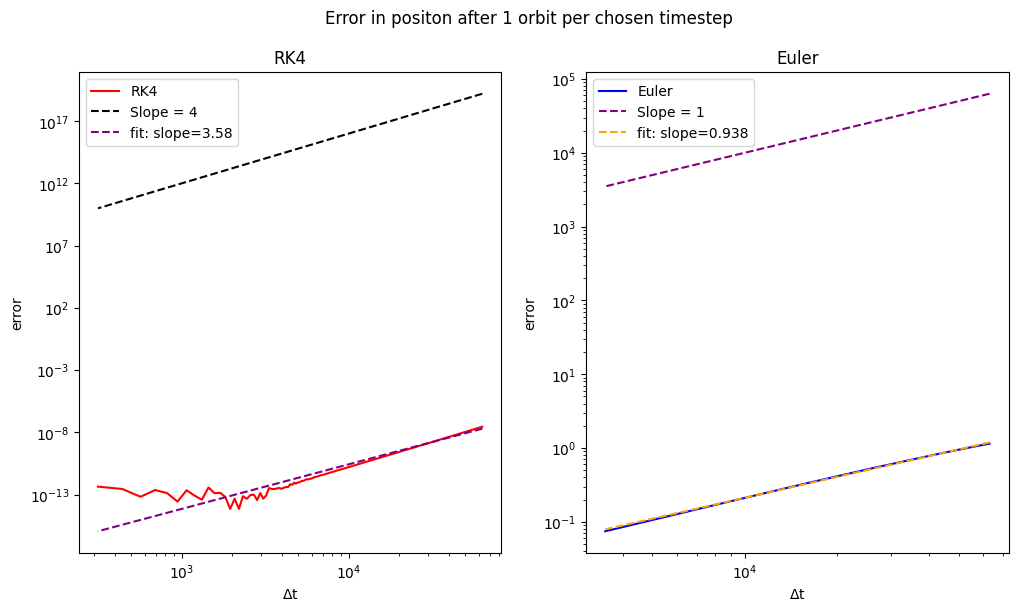

In [19]:
func = tb.kepler_derivs

fig,(ax1, ax2) = plt.subplots(1, 2, figsize = [12,10/1.6])
RK4_arr_err = []
RK4_arr_delta_t = []               
for i in range(len(delta_t_RK4)):
    t, y = it.integrate(it.rk4_step, func, y0, (0, P), delta_t_RK4[i])
    err = np.hypot(*(y[-1, :2] - y0[:2])) / a
    #ax.scatter(delta_t_RK4[i], err, color = 'red')
    RK4_arr_err = np.append(RK4_arr_err, err)
    RK4_arr_delta_t = np.append(RK4_arr_delta_t, delta_t_RK4[i])

Euler_arr_err = []
Euler_arr_delta_t = []  
for i in range(len(delta_t_Euler)):
    t, y = it.integrate(it.euler_step, func, y0, (0, P), delta_t_Euler[i])
    err = np.hypot(*(y[-1, :2] - y0[:2])) / a
    #ax.scatter(delta_t_Euler[i], err, color = 'blue')
    Euler_arr_err = np.append(Euler_arr_err, err)
    Euler_arr_delta_t = np.append(Euler_arr_delta_t, delta_t_Euler[i])

ax1.plot(RK4_arr_delta_t, RK4_arr_err, color = 'red', label = 'RK4')
ax2.plot(Euler_arr_delta_t, Euler_arr_err, color = 'blue', label = 'Euler')

ax1.plot(RK4_arr_delta_t, (RK4_arr_delta_t**4), color = 'black', linestyle = '--', label = 'Slope = 4')
ax2.plot(Euler_arr_delta_t, Euler_arr_delta_t, color = 'purple', linestyle = '--', label = 'Slope = 1')

ax1.set_xscale('log')
ax1.set_yscale('log')
#ax1.set_xlim(5e3, 3e6)
ax1.set_xlabel(r'$\Delta$t')
ax1.set_ylabel('error')
ax1.set_title("RK4")

ax2.set_xscale('log')
ax2.set_yscale('log')
#ax2.set_xlim(5e3, 3e6)
ax2.set_xlabel(r'$\Delta$t')
ax2.set_ylabel('error')
ax2.set_title("Euler")

fig.suptitle("Error in positon after 1 orbit per chosen timestep")

logx_rk4 = np.log10(RK4_arr_delta_t)
logy_rk4 = np.log10(RK4_arr_err)

popt_rk4, pcov_rk4 = curve_fit(f, logx_rk4, logy_rk4)
m_rk4, b_rk4 = popt_rk4
ax1.plot(RK4_arr_delta_t, 10**b_rk4 * RK4_arr_delta_t**m_rk4,
         color='purple', linestyle='--',
         label='fit: slope=%.3g' %m_rk4)

logx_euler = np.log10(Euler_arr_delta_t)
logy_euler = np.log10(Euler_arr_err)

popt_euler, pcov_euler = curve_fit(f, logx_euler, logy_euler)
m_euler, b_euler = popt_euler
ax2.plot(Euler_arr_delta_t, 10**b_euler * Euler_arr_delta_t**m_euler,
         color='orange', linestyle='--',
         label='fit: slope=%.3g' %m_euler)

ax1.legend()
ax2.legend()

#### How do we know it's in the asymptotic regime? This is when the scalings for delta_t are what we predict - 1/2 timestep in Euler follows as a 1/2 reduction in error, and 1/2 reduction in RK4 follows as a 1/16 reduction in error. This occurs at smaller timesteps. 
#### What sets the floor is the numerical precision of the computer, around 1e-14 it seems

### Part (b)

In [20]:
delta_t_fixed = P/500
t_rk4_fixed, y_rk4_fixed = it.integrate(it.rk4_step, tb.kepler_derivs, y0, (0, 100*P), delta_t_fixed, store_every=500)
t_euler, y_euler = it.integrate(it.euler_step, tb.kepler_derivs, y0, (0, 100*P), delta_t_fixed,  store_every=500)

t_rk4_orbit = t_rk4_fixed / P
t_euler_orbit = t_euler / P

In [21]:
drift_rk4 = tb.relative_drift(tb.specific_energy(y_rk4_fixed))
drift_euler = tb.relative_drift(tb.specific_energy(y_euler))

Text(0.5, 0.98, 'Drift in specific energy over 100 orbits for RK4 and Euler Schemes')

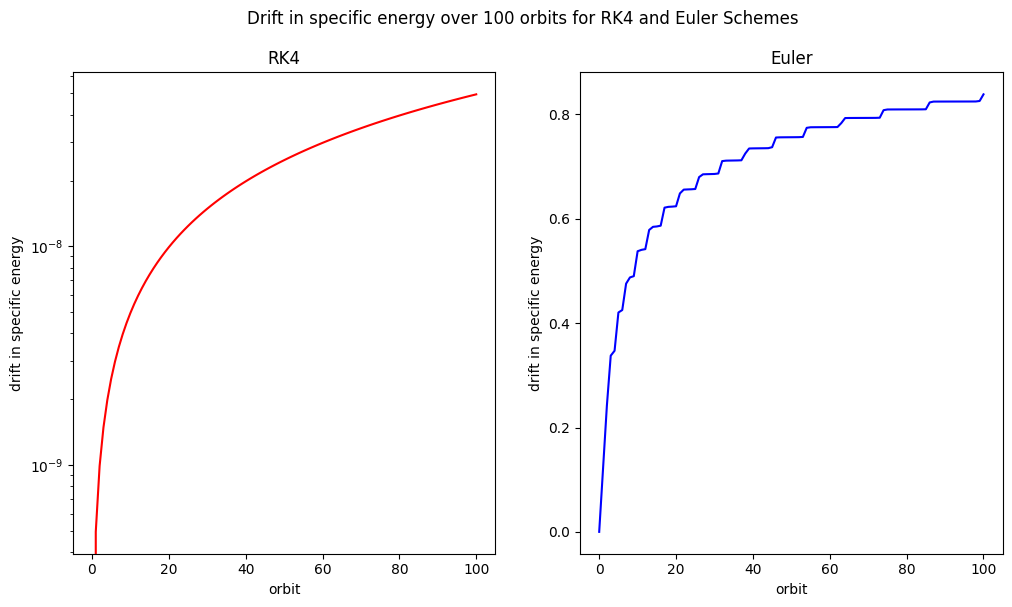

In [22]:
fig,(ax1, ax2) = plt.subplots(1, 2, figsize = [12,10/1.6])

ax1.plot(t_rk4_orbit, np.abs(drift_rk4), color = 'red')
ax2.plot(t_euler_orbit, drift_euler, color = 'blue')


ax1.set_xlabel('orbit')
ax1.set_ylabel('drift in specific energy')
ax1.set_title("RK4")
ax1.set_yscale('log')

ax2.set_xlabel('orbit')
ax2.set_ylabel('drift in specific energy')
ax2.set_title("Euler")

fig.suptitle("Drift in specific energy over 100 orbits for RK4 and Euler Schemes")

In [23]:
drift_E = np.diff(np.abs(drift_rk4))
diff_orbits = np.diff(t_rk4_orbit)
print("The drift per orbit is: %.3g" %np.average(drift_E))

The drift per orbit is: 4.95e-10


### Part (c)

In [24]:
a = c.AU
e_new = 0.9
P = tb.orbital_period(a)
y0_new = tb.initial_conditions(a,e_new)

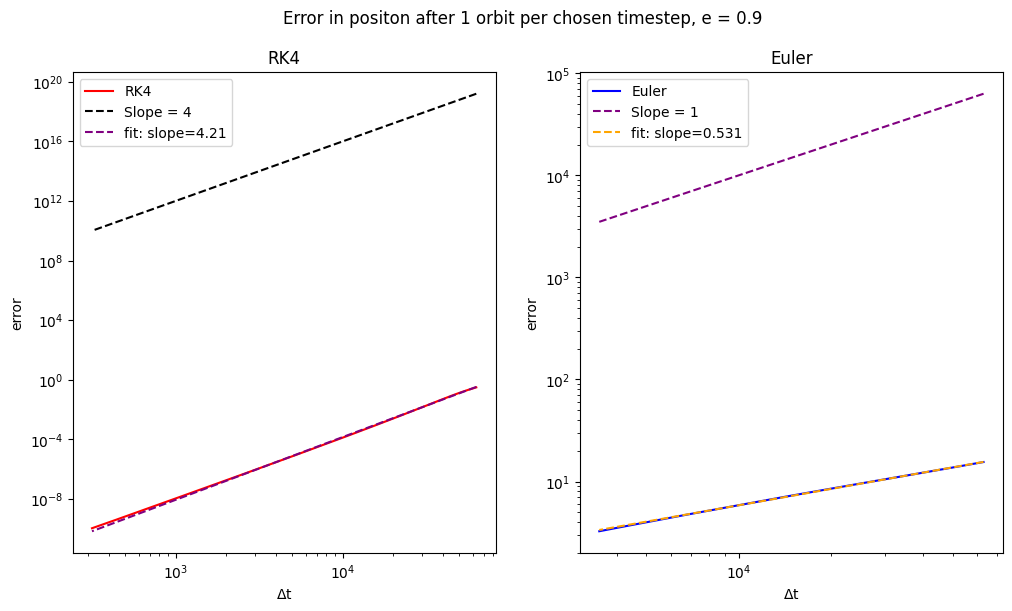

In [25]:
func = tb.kepler_derivs

fig,(ax1, ax2) = plt.subplots(1, 2, figsize = [12,10/1.6])
RK4_arr_err_new = []
RK4_arr_delta_t_new = []               
for i in range(len(delta_t_RK4)):
    t, y = it.integrate(it.rk4_step, func, y0_new, (0, P), delta_t_RK4[i])
    err = np.hypot(*(y[-1, :2] - y0_new[:2])) / a
    #ax.scatter(delta_t_RK4[i], err, color = 'red')
    RK4_arr_err_new = np.append(RK4_arr_err_new, err)
    RK4_arr_delta_t_new = np.append(RK4_arr_delta_t_new, delta_t_RK4[i])

Euler_arr_err_new = []
Euler_arr_delta_t_new = []  
for i in range(len(delta_t_Euler)):
    t, y = it.integrate(it.euler_step, func, y0_new, (0, P), delta_t_Euler[i])
    err = np.hypot(*(y[-1, :2] - y0_new[:2])) / a
    #ax.scatter(delta_t_Euler[i], err, color = 'blue')
    Euler_arr_err_new = np.append(Euler_arr_err_new, err)
    Euler_arr_delta_t_new = np.append(Euler_arr_delta_t_new, delta_t_Euler[i])

ax1.plot(RK4_arr_delta_t_new, RK4_arr_err_new, color = 'red', label = 'RK4')
ax2.plot(Euler_arr_delta_t_new, Euler_arr_err_new, color = 'blue', label = 'Euler')

ax1.plot(RK4_arr_delta_t_new, (RK4_arr_delta_t_new**4), color = 'black', linestyle = '--', label = 'Slope = 4')
ax2.plot(Euler_arr_delta_t_new, Euler_arr_delta_t_new, color = 'purple', linestyle = '--', label = 'Slope = 1')

ax1.set_xscale('log')
ax1.set_yscale('log')
#ax1.set_xlim(5e3, 3e6)
ax1.set_xlabel(r'$\Delta$t')
ax1.set_ylabel('error')
ax1.set_title("RK4")

ax2.set_xscale('log')
ax2.set_yscale('log')
#ax2.set_xlim(5e3, 3e6)
ax2.set_xlabel(r'$\Delta$t')
ax2.set_ylabel('error')
ax2.set_title("Euler")

fig.suptitle("Error in positon after 1 orbit per chosen timestep, e = 0.9")

logx_rk4 = np.log10(RK4_arr_delta_t_new)
logy_rk4 = np.log10(RK4_arr_err_new)

popt_rk4, pcov_rk4 = curve_fit(f, logx_rk4, logy_rk4)
m_rk4, b_rk4 = popt_rk4
ax1.plot(RK4_arr_delta_t_new, 10**b_rk4 * RK4_arr_delta_t_new**m_rk4,
         color='purple', linestyle='--',
         label='fit: slope=%.3g' %m_rk4)

logx_euler = np.log10(Euler_arr_delta_t_new)
logy_euler = np.log10(Euler_arr_err_new)

popt_euler, pcov_euler = curve_fit(f, logx_euler, logy_euler)
m_euler, b_euler = popt_euler
ax2.plot(Euler_arr_delta_t_new, 10**b_euler * Euler_arr_delta_t_new**m_euler,
         color='orange', linestyle='--',
         label='fit: slope=%.3g' %m_euler)
#popt_rk4, pcov_rk4 = curve_fit(f, RK4_arr_delta_t, RK4_arr_err)
#ax1.plot(RK4_arr_delta_t, f(RK4_arr_delta_t, *popt_rk4), color = 'green', linestyle = '--', label='fit: slope=%.3g, y-intercept=%.3g' % tuple(popt_rk4))

#popt_euler, pcov_euler = curve_fit(f, Euler_arr_delta_t, Euler_arr_err)
#ax.plot(Euler_arr_delta_t, f(Euler_arr_delta_t, *popt_euler), color = 'purple', linestyle = '--', label='fit: slope=%.3g, y-intercept=%.3g' % tuple(popt_euler))

ax1.legend()
ax2.legend()

### Part (d)

### $n$ = $\frac{10^{-3}}{Drift}$

In [26]:
n = 1e-3 / np.average(drift_E)
print("The drift in specific energy reaches 1e-3 at n = %.3g orbits" %n)

The drift in specific energy reaches 1e-3 at n = 2.02e+06 orbits


#### This result does not support my 100-orbit result, since the drift in speifc energy over time is not linear, but the above result assumes the accumulation of error is linear

### Part (e)

#### I need to run rk4 for longer to get an error of 1e-6:

In [27]:
t_rk4_long, y_rk4_long= it.integrate(it.rk4_step, tb.kepler_derivs, y0, (0, 5000*P), delta_t_fixed, store_every=500)

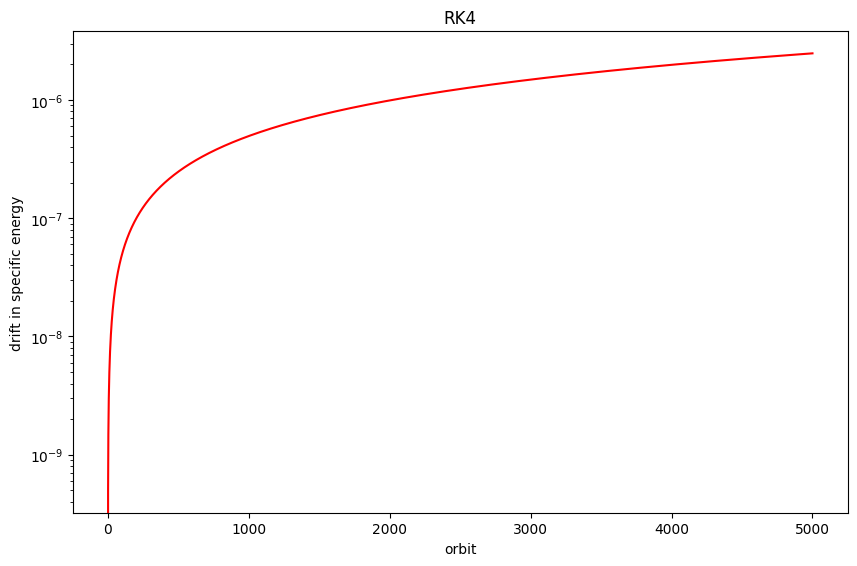

In [28]:
t_rk4_orbit_long = t_rk4_long / P
drift_rk4_long = tb.relative_drift(tb.specific_energy(y_rk4_long))

fig, ax = plt.subplots(figsize=[10,10/1.6])
ax.plot(t_rk4_orbit_long, np.abs(drift_rk4_long), color = 'red')
ax.set_xlabel('orbit')
ax.set_ylabel('drift in specific energy')
ax.set_title("RK4")
ax.set_yscale('log')

In [29]:
print("The orbit where the drift in specific energy reaches 1e-6 is: %.4g orbits" %(np.argwhere(np.abs(drift_rk4_long) >= 1e-6)[0]))

The orbit where the drift in specific energy reaches 1e-6 is: 2019 orbits


#### A smaller timestep postpones the crossing because the drift is directly proportional to the timestep. All decreasing the timestep does is lower the drift per orbit, postponing the error without removing it entirely

## Problem 4: The Hill Radius and the Edge of a Satellite System

In [45]:
planet_data = pd.read_csv("data/ps2/planet_elements.csv")

### Part (a)

In [31]:
a_arr = c.AU * np.array(planet_data["a_au"])
e_arr = np.array(planet_data["e"])
mass_arr = np.array(planet_data["mass_kg"])
radius_arr = np.array(planet_data["radius_m"])

In [32]:
hill_rad_arr = []
for i in range(len(a_arr)):
    hill_radius = tb.hill_radius(a=a_arr[i],m_planet=mass_arr[i],e=e_arr[i])
    hill_rad_arr = np.append(hill_rad_arr, hill_radius)

In [33]:
frac_diff_hill = (r_H_calc - hill_rad_arr[2]) / r_H_calc
print("The fractional difference between the calculated Hill Radius, and the Hill Radius from Q#1 is: %.2g" %frac_diff_hill)

The fractional difference between the calculated Hill Radius, and the Hill Radius from Q#1 is: 0.017


### Part (b)

#### For a satellite orbiting a planet at its Hill radius, its period would be:

#### $P_{SAT} = 2\pi \sqrt{\frac{r_{H}^{3}}{Gm_{p}}}$
#### $P_{SAT} = 2\pi \sqrt{\frac{a^{3}m_{p}}{3GM_{Sun}m_{p}}}$
#### $P_{SAT} = 2\pi \sqrt{\frac{a^{3}}{3GM_{Sun}}} = \frac{1}{\sqrt{3}}2\pi \sqrt{\frac{a^{3}}{GM_{Sun}}} = \frac{1}{\sqrt{3}}P_{p}$

#### If the satellite were orbiting at 0.5$r_{H}$ :

#### $P_{SAT} = 2\pi \sqrt{\frac{0.5(a)^{3}}{3GM_{Sun}}} = \sqrt{\frac{0.5}{{3}}}P_{p} = \frac{1}{\sqrt{6}}P_{p}$

### Part (c)

In [42]:
sat_data = pd.read_csv("data/ps2/satellites.csv")

In [35]:
prograde_all = sat_data.loc[sat_data['direction'] == 'prograde']
retrograde_all = sat_data.loc[sat_data['direction'] == 'retrograde']

In [36]:
prograde_J = prograde_all.loc[prograde_all['planet'] == 'Jupiter']
prograde_S = prograde_all.loc[prograde_all['planet'] == 'Saturn']
prograde_U = prograde_all.loc[prograde_all['planet'] == 'Uranus']
prograde_N = prograde_all.loc[prograde_all['planet'] == 'Neptune']

retrograde_J = retrograde_all.loc[retrograde_all['planet'] == 'Jupiter']
retrograde_S = retrograde_all.loc[retrograde_all['planet'] == 'Saturn']
retrograde_U = retrograde_all.loc[retrograde_all['planet'] == 'Uranus']
retrograde_N = retrograde_all.loc[retrograde_all['planet'] == 'Neptune']

In [37]:
max_prograde_J = np.max(prograde_J["a_m"])
max_retrograde_J = np.max(retrograde_J["a_m"])

max_prograde_S = np.max(prograde_S["a_m"])
max_retrograde_S = np.max(retrograde_S["a_m"])

max_prograde_U = np.max(prograde_U["a_m"])
max_retrograde_U = np.max(retrograde_U["a_m"])

max_prograde_N = np.max(prograde_N["a_m"])
max_retrograde_N = np.max(retrograde_N["a_m"])

In [38]:
J_hill_rad = hill_rad_arr[4]
S_hill_rad = hill_rad_arr[5]
U_hill_rad = hill_rad_arr[6]
N_hill_rad = hill_rad_arr[7]

In [39]:
satellites_pro  = [max_prograde_J, max_prograde_S, max_prograde_U, max_prograde_N]
hill_radii = [J_hill_rad, S_hill_rad, U_hill_rad, N_hill_rad]

rows = []
for s, h in zip(satellites_pro, hill_radii):
    df = sat_data.loc[(sat_data["a_m"] == s), ["planet", "name", "a_m", "direction"]]
    df["a_m"] = df["a_m"]/h
    rows.append(df)

satellites_retro  = [max_retrograde_J, max_retrograde_S, max_retrograde_U, max_retrograde_N]
for s, h in zip(satellites_retro, hill_radii):
    df = sat_data.loc[(sat_data["a_m"] == s), ["planet", "name", "a_m", "direction"]]
    df["a_m"] = df["a_m"]/h
    rows.append(df)


In [44]:
table = pd.concat(rows, ignore_index=True)
table

,planet,name,a_m,direction
0,Jupiter,Valetudo,0.369616,prograde
1,Saturn,S/2004_S_24,0.378555,prograde
2,Uranus,Margaret,0.216029,prograde
3,Neptune,Laomedeia,0.204261,prograde
4,Jupiter,Kore,0.478645,retrograde
5,Saturn,S/2020_S_44,0.442158,retrograde
6,Uranus,Ferdinand,0.305831,retrograde
7,Neptune,S/2021_N_1,0.440685,retrograde


### Part (d)

#### $\rho_{R} = \rho_{S}(\frac{1.44R_{S}}{a})^{3}$
#### $\rho_{F} = \rho_{S}(\frac{2.44R_{S}}{a})^{3}$

In [41]:
d = 1.368e8 #m
R_S = 58232000.0 #m, from the planet elements table
density_S = 5.683400e26 /( (4/3) * np.pi * (R_S)**3) # mass / volume of a sphere

density_rigid = density_S * ((1.44 * R_S) / d)**3
density_fluid = density_S * ((2.44 * R_S) / d)**3

print("The density for the rigid criterion to place the disruption boundary at the outer edge of Saturn's A ring is: %.3g kg m^-3" %density_rigid)
print("The density for the fluid criterion to place the disruption boundary at the outer edge of Saturn's A ring is: %.3g kg m^-3" %density_fluid)

The density for the rigid criterion to place the disruption boundary at the outer edge of Saturn's A ring is: 158 kg m^-3
The density for the fluid criterion to place the disruption boundary at the outer edge of Saturn's A ring is: 770 kg m^-3


#### I would say the fluid criterion is plausible for water ice. The density of water ice is around 1000 kg/m^3, so since this density is less than the density of water ice, this material is less strong than water ice. This makes sense, since Saturn's rings are not made of a rigid body of water ice. 

### Part (e)

#### From the results in the table for part (c), the prograde limit is between 0.2-0.37$r_{H}$, whereas the retrograde limit is between 0.3-0.47$r_{H}$. Material near $r_{H}$ is only marginally bound, since it approaches the influence of other planetary bodies that would perturb its orbit. From part (b), a satellite orbiting near/at $r_{H}$ completes $1/\sqrt{3}$ orbits per 1 orbit of the planet. This pattern results in a resonance orbit between the planet and the satellite. This resonance could result in tidal forces that eventually impact the orbit of the satllite, and that small force could push the satellite either out of the hill sphere of the planet, or into a closer orbit.